# 2.7 

The file `w_logret_3automanu.txt` contains the weekly log returns of three auto manufacturers, General Motors Corp., Ford Motor Corp., and Toyota Motor Corp., from the week of January 3, 1994 to the week of June 25, 2007.

(a) Write down the sample covariance matrix $\hat{V}$ of these returns.

Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
from itertools import combinations

from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import f, t

import seaborn as sns
from scipy import stats

from scipy.optimize import minimize

plt.rcParams['text.usetex'] = True

In [2]:
# Load dataset
auto_returns = pd.read_csv('w_logret_3automanu.csv', 
                          usecols=[1, 2, 3], header=0)

In [3]:
# Compute sample covariance matrix
S = auto_returns.cov()
print("Sample covariance matrix S:")
print(S)

Sample covariance matrix S:
          Toyota      Ford        GM
Toyota  0.000259  0.000076  0.000063
Ford    0.000076  0.000378  0.000237
GM      0.000063  0.000237  0.000396


(b) For each pair of these three automotive companies, construct a 95% confidence interval for their return correlation coefficients


From Exercise 2.6(b), we have the asymptotic distribution:

$$\begin{equation*}
\sqrt{n}(\hat{\rho} - \rho) \stackrel{d}{\to} N\left(0, (1-\rho^2)^2\right)
\end{equation*}$$

For large $n$:

$$\begin{equation*}
\hat{\rho} \approx N\left(\rho, \frac{(1-\rho^2)^2}{n}\right)
\end{equation*}$$

Using the Fisher z-transformation to ensure confidence intervals remain within $[-1, 1]$:
$$
\begin{align*}
\hat{z} &= \mathrm{arctanh}(\hat{\rho}) \
\zeta &= \mathrm{arctanh}(\rho)
\end{align*}
$$

The asymptotic distribution becomes:
$$
\begin{equation*}
\hat{z} \approx N\left(\zeta, \frac{1}{n}\right)
\end{equation*}$$

The 95% confidence interval for $\zeta$:
$$
\begin{equation*}
\hat{z} \pm 1.96 \cdot \frac{1}{\sqrt{n}}
\end{equation*}
$$

Transforming back to the correlation scale:
$$
\begin{align*}
\rho_{\text{lower}} &= \tanh\left(\hat{z} - \frac{1.96}{\sqrt{n}}\right) \
\rho_{\text{upper}} &= \tanh\left(\hat{z} + \frac{1.96}{\sqrt{n}}\right)
\end{align*}
$$

In [4]:
sample_size = len(auto_returns)
stock_combinations = list(combinations(auto_returns.columns, 2))

for company1, company2 in stock_combinations:
    corr_coef = auto_returns[company1].corr(auto_returns[company2])
    
    # Fisher z-transformation
    fisher_z = np.arctanh(corr_coef)
    fisher_z_se = 1 / np.sqrt(sample_size)
    
    # 95% CI for z
    fisher_z_lower = fisher_z - 1.96 * fisher_z_se
    fisher_z_upper = fisher_z + 1.96 * fisher_z_se
    
    # Transform back to correlation scale
    corr_lower = np.tanh(fisher_z_lower)
    corr_upper = np.tanh(fisher_z_upper)
    
    print(f"{company1} vs {company2}:")
    print(f"  Sample correlation coefficient = {corr_coef:.4f}")
    print(f"  95% confidence interval = ({corr_lower:.4f}, {corr_upper:.4f})")
    print()

Toyota vs Ford:
  Sample correlation coefficient = 0.2425
  95% confidence interval = (0.1720, 0.3104)

Toyota vs GM:
  Sample correlation coefficient = 0.1952
  95% confidence interval = (0.1235, 0.2649)

Ford vs GM:
  Sample correlation coefficient = 0.6125
  95% confidence interval = (0.5644, 0.6564)



(c) Assumptions and Graphical Validation

The statistical inference in part (b) relies on:

* Reasonable approximation of bivariate normality
* Independent and identically distributed observations
* Sufficiently large sample size for asymptotic approximations

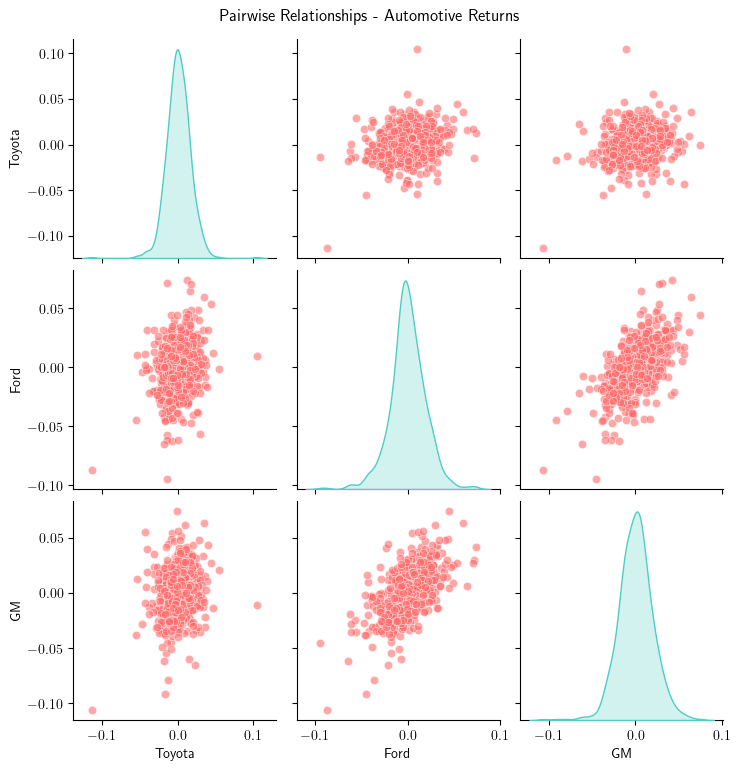

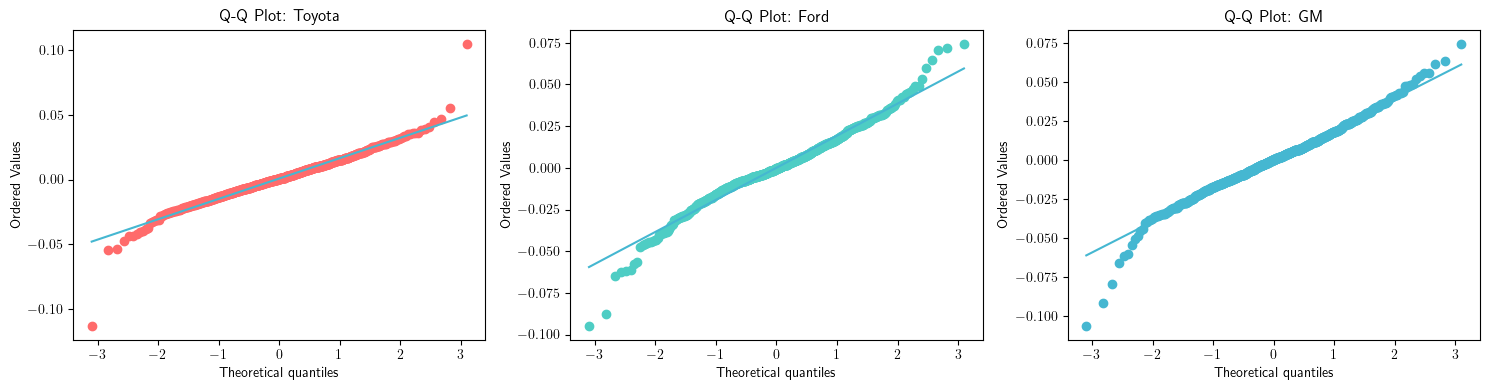

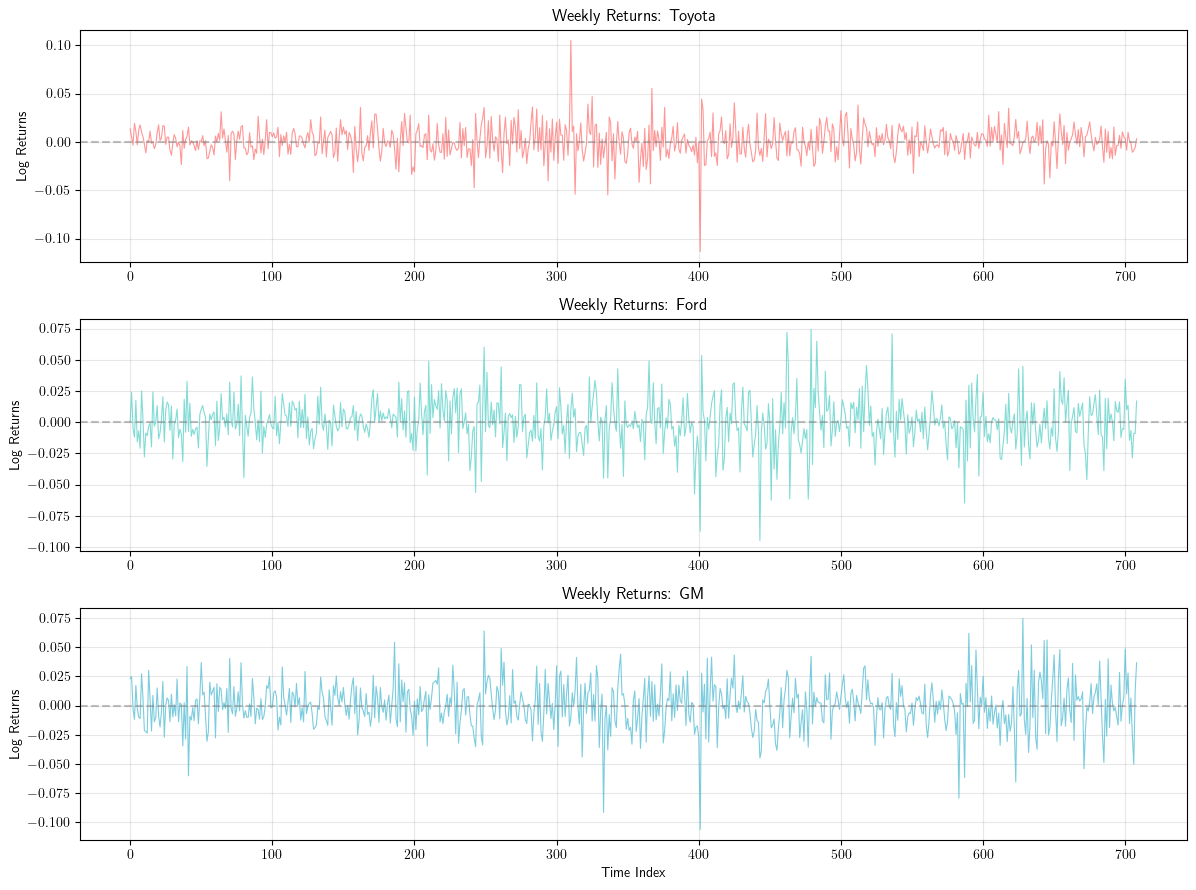

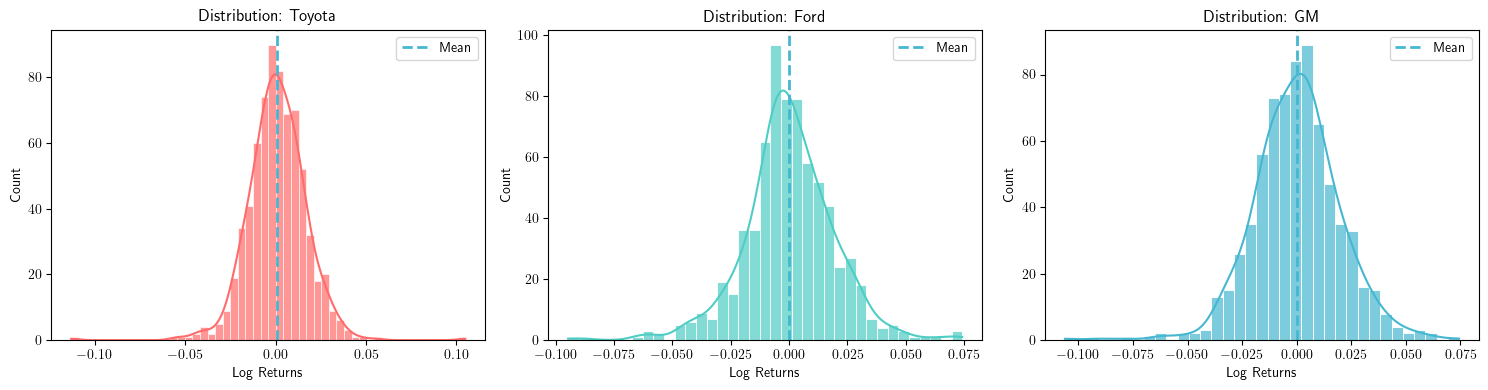

In [5]:
# Color scheme
plt_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Coral, Turquoise, Sky Blue

# Create pairwise scatter plots
pair_grid = sns.pairplot(auto_returns, diag_kind='kde', 
                         plot_kws={'alpha': 0.6, 'color': plt_colors[0]},
                         diag_kws={'color': plt_colors[1]})
pair_grid.fig.suptitle('Pairwise Relationships - Automotive Returns', y=1.02)
plt.show()

# Generate Q-Q plots for each company
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (company, color) in enumerate(zip(auto_returns.columns, plt_colors)):
    stats.probplot(auto_returns[company].dropna(), dist="norm", plot=axes[idx])
    axes[idx].get_lines()[0].set_markerfacecolor(color)
    axes[idx].get_lines()[0].set_markeredgecolor(color)
    axes[idx].get_lines()[1].set_color(plt_colors[2])  # Different color for reference line
    axes[idx].set_title(f'Q-Q Plot: {company}')
    axes[idx].set_ylabel('Ordered Values')

plt.tight_layout()
plt.show()

# Time series visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for idx, (company, color) in enumerate(zip(auto_returns.columns, plt_colors)):
    axes[idx].plot(auto_returns.index, auto_returns[company], 
                   color=color, alpha=0.7, linewidth=0.8)
    axes[idx].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[idx].set_ylabel('Log Returns')
    axes[idx].set_title(f'Weekly Returns: {company}')
    axes[idx].grid(True, alpha=0.3)

plt.xlabel('Time Index')
plt.tight_layout()
plt.show()

# Distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (company, color) in enumerate(zip(auto_returns.columns, plt_colors)):
    sns.histplot(auto_returns[company], kde=True, ax=axes[idx], 
                 color=color, edgecolor='white', alpha=0.7)
    axes[idx].axvline(x=auto_returns[company].mean(), color=plt_colors[2], 
                      linestyle='--', linewidth=2, label='Mean')
    axes[idx].set_title(f'Distribution: {company}')
    axes[idx].set_xlabel('Log Returns')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# 3.4 

Let $\widehat{\boldsymbol{\mu}}$ and $\widehat{\boldsymbol{\Sigma}}$ denote the sample mean and the sample covariance matrix of the observed sample $\{{\bf r}_{1},\ldots,{\bf r}_{n}\}$, and let $\widehat{\mathbf{w}}_{b}^{*}$ be the estimated optimal portfolio weight vector based on the $b$-th bootstrap sample $\{{\bf r}_{b1}^{*},\ldots,{\bf r}_{bn}^{*}\}$ drawn with replacement from the observed sample $\{{\bf r}_{1},\ldots,{\bf r}_{n}\}$. The file `d_logret_6stocks.txt` contains the log returns of six stocks in  Section 3.2.4.

(a) Use one bootstrap sample to plot the curve $\left( \sqrt{(\widehat{\mathbf{w}}_b^*)^{\!\top} \widehat{\boldsymbol{\Sigma}} \,\widehat{\mathbf{w}}_b^*}, \; (\widehat{\mathbf{w}}_b^*)^{\!\top} \widehat{\boldsymbol{\mu}} \right)$ for different target mean returns $\mu_*$.

In [6]:
# Load the dataset
raw_market_data = pd.read_csv('d_logret_6stocks.csv')

# Drop Date column
stock_log_returns = raw_market_data.drop('Date', axis=1)

# Convert to matrix
ret_matrix = stock_log_returns.values
num_obs, num_assets = ret_matrix.shape

(a) Use one bootstrap sample to plot the curve $\left( \sqrt{(\widehat{\mathbf{w}}_b^*)^{\!\top} \widehat{\boldsymbol{\Sigma}} \,\widehat{\mathbf{w}}_b^*}, \; (\widehat{\mathbf{w}}_b^*)^{\!\top} \widehat{\boldsymbol{\mu}} \right)$ for different target mean returns $\mu_*$.

In [7]:
def solve_frontier_weights(mean_vec, cov_mat, target_r):
    """
    Calculates optimal portfolio weights for a specific target return.
    Renamed from 'markowitz_optimizer'
    """
    num_assets = len(mean_vec)
    
    # Objective: Minimize Variance
    def var_func(w):
        return w @ cov_mat @ w

    # Initial guess (equal weights)
    init_guess = np.ones(num_assets) / num_assets
    
    # Bounds: 0 <= w <= 1 (no short selling)
    limitations = tuple((0, 1) for _ in range(num_assets))
    
    # Constraints: sum(w) = 1, w @ mu = target
    conditions = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: w @ mean_vec - target_r}
    ]
    
    # Optimization
    opt_res = minimize(var_func, init_guess, method='SLSQP', 
                       bounds=limitations, constraints=conditions,
                       options={'maxiter': 1000, 'ftol': 1e-8})
    
    if opt_res.success:
        return opt_res.x
    else:
        # Fallback if specific target fails: global min variance
        min_cond = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
        fallback_res = minimize(var_func, init_guess, method='SLSQP',
                                bounds=limitations, constraints=min_cond)
        return fallback_res.x if fallback_res.success else init_guess

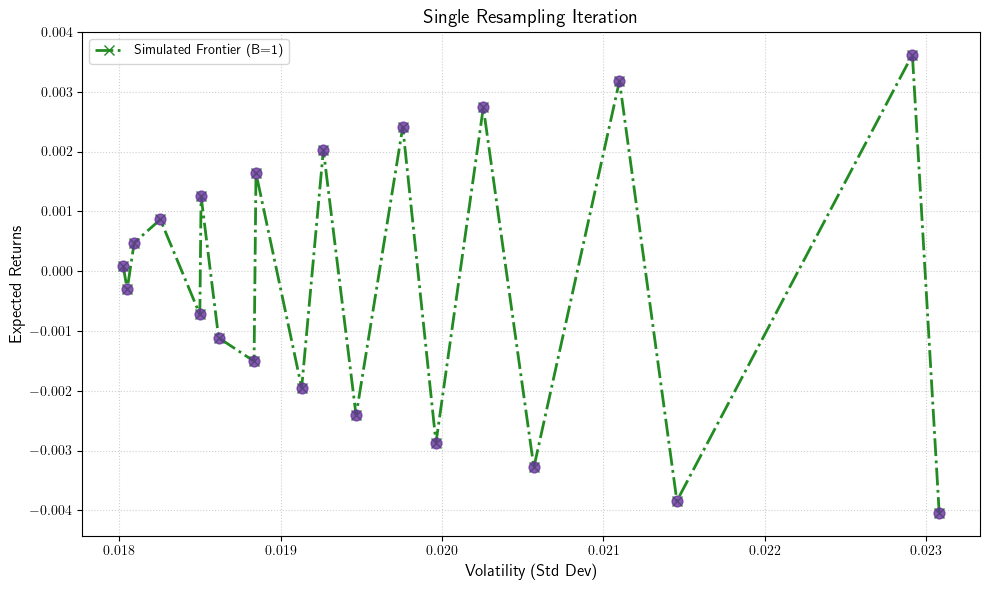

In [8]:
np.random.seed(101) # Seed

# Original Sample Stats
emp_means = np.mean(ret_matrix, axis=0)
emp_cov = np.cov(ret_matrix, rowvar=False)

# Generate one resampled dataset
sample_indices = np.random.choice(num_obs, size=num_obs, replace=True)
resampled_data = ret_matrix[sample_indices]

# Compute stats for this sample
resampled_means = np.mean(resampled_data, axis=0)
resampled_cov = np.cov(resampled_data, rowvar=False)

# Grid for frontier
y_min = np.min(resampled_means)
y_max = np.max(resampled_means)
grid_returns = np.linspace(y_min, y_max, 20)

single_boot_frontier = []

for r_target in grid_returns:
    # Get optimal weights based on resampled data
    w_opt = solve_frontier_weights(resampled_means, resampled_cov, r_target)
    
    # Evaluate using ORIGINAL (empirical) parameters
    true_ret = w_opt @ emp_means
    true_vol = np.sqrt(w_opt @ emp_cov @ w_opt)
    
    single_boot_frontier.append((true_vol, true_ret))

single_boot_frontier = np.array(single_boot_frontier)

# Sort for plotting
sort_order = np.argsort(single_boot_frontier[:, 0])
plot_data = single_boot_frontier[sort_order]

# Plotting with different colors/styles
plt.figure(figsize=(10, 6))

plt.plot(plot_data[:, 0], plot_data[:, 1], 
         color='forestgreen', linestyle='-.', linewidth=2, 
         marker='x', markersize=7, label='Simulated Frontier (B=1)')

plt.scatter(plot_data[:, 0], plot_data[:, 1], 
            color='rebeccapurple', s=60, alpha=0.8, zorder=5)

plt.xlabel('Volatility (Std Dev)', fontsize=12)
plt.ylabel('Expected Returns', fontsize=12)
plt.title('Single Resampling Iteration', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

(b) Repeat (a) for $B = 10$ bootstrap samples. Explain why all the plotted curves are below the estimated efficient frontier based on $\widehat{\boldsymbol{\mu}}$ and $\widehat{\boldsymbol{\Sigma}}$.

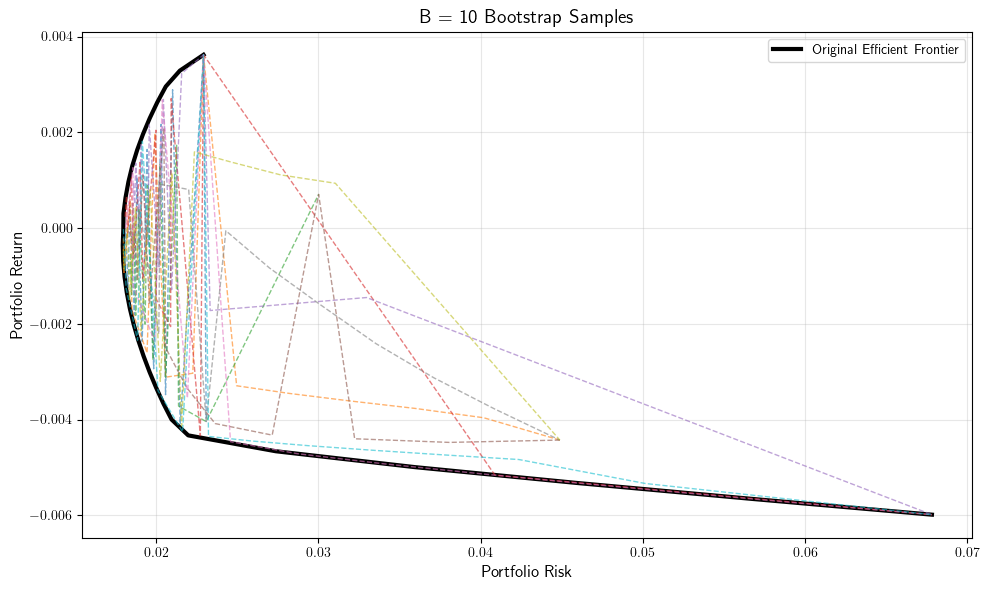

In [9]:
B = 10
plt.figure(figsize=(10, 6))

# Plot original efficient frontier for comparison
orig_targets = np.linspace(np.min(emp_means), np.max(emp_means), 30)
orig_frontier = []
for target in orig_targets:
    w_orig = solve_frontier_weights(emp_means, emp_cov, target)
    orig_return = w_orig @ emp_means
    orig_risk = np.sqrt(w_orig @ emp_cov @ w_orig)
    orig_frontier.append((orig_risk, orig_return))

orig_frontier_array = np.array(orig_frontier)
plt.plot(orig_frontier_array[:, 0], orig_frontier_array[:, 1], 
         'k-', linewidth=3, label='Original Efficient Frontier')

# Generate B bootstrap samples
for b in range(B):
    bootstrap_idx = np.random.choice(num_obs, size=num_obs, replace=True)
    bootstrap_sample = ret_matrix[bootstrap_idx]
    mu_boot = np.mean(bootstrap_sample, axis=0)
    Sigma_boot = np.cov(bootstrap_sample, rowvar=False)
    
    min_target = np.min(mu_boot)
    max_target = np.max(mu_boot)
    target_returns_boot = np.linspace(min_target, max_target, 15)
    
    bootstrap_curve = []
    for target in target_returns_boot:
        w_star = solve_frontier_weights(mu_boot, Sigma_boot, target)
        eval_return = w_star @ emp_means
        eval_risk = np.sqrt(w_star @ emp_cov @ w_star)
        bootstrap_curve.append((eval_risk, eval_return))
    
    bootstrap_curve = np.array(bootstrap_curve)
    sort_idx = np.argsort(bootstrap_curve[:, 0])
    plt.plot(bootstrap_curve[sort_idx, 0], bootstrap_curve[sort_idx, 1], 
             '--', alpha=0.6, linewidth=1)

plt.xlabel('Portfolio Risk', fontsize=12)
plt.ylabel('Portfolio Return', fontsize=12)
plt.title('B = 10 Bootstrap Samples', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(c) Compute Michaud's resampled efficient frontier by using $B = 500$ bootstrap samples.

In [13]:
B = 500
n_targets_michaud = 20

# Use original mean range for target return grid
min_target = np.min(emp_means)
max_target = np.max(emp_means)
target_returns_grid = np.linspace(min_target, max_target, n_targets_michaud)

# Store average weights for each target return
averaged_weights = []

for i, target in enumerate(target_returns_grid):
    weights_for_target = []
    
    for b in range(B):
        bootstrap_idx = np.random.choice(num_obs, size=num_obs, replace=True)
        bootstrap_sample = ret_matrix[bootstrap_idx]
        mu_boot = np.mean(bootstrap_sample, axis=0)
        Sigma_boot = np.cov(bootstrap_sample, rowvar=False)
        
        w_opt = solve_frontier_weights(mu_boot, Sigma_boot, target)
        weights_for_target.append(w_opt)
    
    # Average weights across bootstrap samples
    avg_w = np.mean(weights_for_target, axis=0)
    avg_w = avg_w / np.sum(avg_w)  # Normalize
    averaged_weights.append(avg_w)

# Evaluate averaged weights using original statistics
michaud_returns = []
michaud_risks = []

for w_avg in averaged_weights:
    portfolio_return = w_avg @ emp_means
    portfolio_risk = np.sqrt(w_avg @ emp_cov @ w_avg)
    michaud_returns.append(portfolio_return)
    michaud_risks.append(portfolio_risk)

# Sort by return for plotting
sort_idx = np.argsort(michaud_returns)
michaud_returns_sorted = np.array(michaud_returns)[sort_idx]
michaud_risks_sorted = np.array(michaud_risks)[sort_idx]

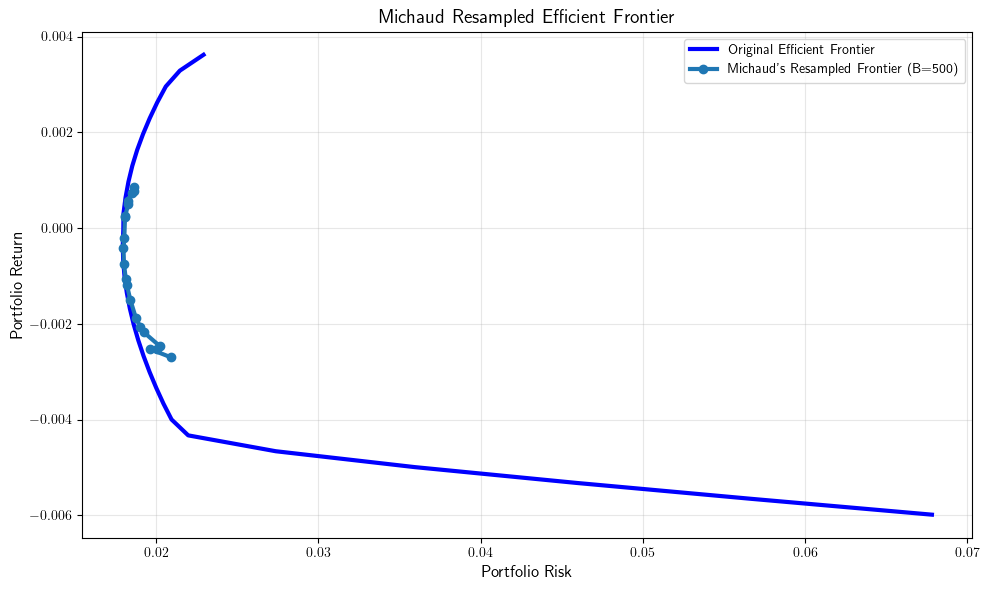

In [14]:
# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(orig_frontier_array[:, 0], orig_frontier_array[:, 1],
         'b-', linewidth=3, label='Original Efficient Frontier')
plt.plot(michaud_risks_sorted, michaud_returns_sorted,
         'o-', linewidth=3, label=f"Michaud's Resampled Frontier (B={B})")

plt.xlabel('Portfolio Risk', fontsize=12)
plt.ylabel('Portfolio Return', fontsize=12)
plt.title('Michaud Resampled Efficient Frontier', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3.5 



In [15]:
# Load the dataset
asset_data = pd.read_csv('m_ret_10stocks.csv')

# Prepare the matrix
log_returns_matrix = asset_data.drop('Date', axis=1).values
n_rows, n_cols = log_returns_matrix.shape

def calculate_optimal_allocation(expected_v, risk_mat, target_yield):
    """
    Computes the weights for minimum variance at a given target return.
    """
    num_assets = len(expected_v)
    
    # Objective: Minimize Portfolio Variance (w.T * Sigma * w)
    def objective_risk(w):
        return w @ risk_mat @ w

    # Initial guess: Equal weights
    start_w = np.ones(num_assets) / num_assets
    
    # Constraints: 
    # 1. Sum of weights = 1
    # 2. Portfolio return = target_yield
    cons = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: w @ expected_v - target_yield}
    )
    
    # Bounds: No short selling (0 <= w <= 1)
    bnds = tuple((0, 1) for _ in range(num_assets))
    
    # Optimization
    solution = minimize(objective_risk, start_w, method='SLSQP', 
                        bounds=bnds, constraints=cons)
    
    return solution.x if solution.success else start_w

(a)  Compute the sample mean $\hat{\mu}$ and the sample covariance matrix $\hat{\Sigma}$ of
the log returns

In [16]:
data = pd.read_csv('m_ret_10stocks.csv', index_col='Date')

# Assuming data contains simple returns, convert to log returns
log_returns = np.log(1 + data)

stock_names = ['Apple Computer', 'Adobe Systems', 'Automatic Data Processing', 
               'Advanced Micro Devices', 'Dell', 'Gateway', 
               'Hewlett-Packard Company', 'International Business Machines Corp.', 
               'Microsoft Corp.', 'Oracle Corp.']

# Part (a): Compute sample mean and covariance matrix
def compute_sample_stats(returns):
    """Compute sample mean and covariance matrix"""
    mu_hat = returns.mean().values
    sigma_hat = returns.cov().values
    return mu_hat, sigma_hat

emp_means, sigma_hat = compute_sample_stats(log_returns)
print("Part (a):")
print(f"Sample mean vector shape: {emp_means.shape}")
print(f"Sample covariance matrix shape: {sigma_hat.shape}")
print("\nSample means (%):")
for i, (name, mu) in enumerate(zip(stock_names, emp_means)):
    print(f"{i+1:2d}. {name:40s}: {mu*100:.4f}%")

Part (a):
Sample mean vector shape: (10,)
Sample covariance matrix shape: (10, 10)

Sample means (%):
 1. Apple Computer                          : 0.4467%
 2. Adobe Systems                           : 0.5424%
 3. Automatic Data Processing               : 0.3526%
 4. Advanced Micro Devices                  : -0.1282%
 5. Dell                                    : 1.0105%
 6. Gateway                                 : -0.6011%
 7. Hewlett-Packard Company                 : 0.3863%
 8. International Business Machines Corp.   : 0.4933%
 9. Microsoft Corp.                         : 0.6268%
10. Oracle Corp.                            : 0.5002%


In [17]:
print(f"Sample Mean Vector μ̂ (monthly returns):")
print(emp_means) 

print(f"\nSample Covariance Matrix Σ̂ (monthly covariances):")
print(sigma_hat)

Sample Mean Vector μ̂ (monthly returns):
[ 0.00446683  0.00542375  0.00352555 -0.00128225  0.01010538 -0.00601147
  0.00386293  0.00493292  0.0062682   0.00500237]

Sample Covariance Matrix Σ̂ (monthly covariances):
[[5.05650897e-03 1.33970557e-03 1.06699185e-04 2.80212504e-03
  2.04175060e-03 2.41904135e-03 7.37813401e-04 9.95112733e-04
  9.32475719e-04 1.40304445e-03]
 [1.33970557e-03 4.56337212e-03 5.21531940e-04 1.81002384e-03
  1.19071367e-03 2.05151131e-03 6.67219581e-04 4.37167171e-04
  6.09436343e-04 1.14673225e-03]
 [1.06699185e-04 5.21531940e-04 7.83947431e-04 5.09311662e-04
  3.69333225e-04 5.81831801e-04 2.94421914e-04 4.09784829e-04
  3.19033690e-04 3.60789539e-04]
 [2.80212504e-03 1.81002384e-03 5.09311662e-04 7.29464939e-03
  2.06239384e-03 3.45728568e-03 9.14428436e-04 1.61224387e-03
  1.20147746e-03 1.61026267e-03]
 [2.04175060e-03 1.19071367e-03 3.69333225e-04 2.06239384e-03
  3.47281979e-03 2.77095423e-03 5.23997919e-04 1.04288507e-03
  1.57163406e-03 1.20432273e-03]

(b) Assume that the monthly target return is $0.3\%$ and that short selling is allowed. Estimate the optimal portfolio weights by replacing $(\mu, \Sigma)$ in Markowitz’s theory by $\hat{\mu}, \hat{\Sigma}$.

In [18]:
# Part (b): Markowitz optimal portfolio with target return 0.3%
def markowitz_optimal_weights(mu_target, mu_est, sigma_est):
    """Compute Markowitz optimal portfolio weights for given target return"""
    n = len(mu_est)
    
    # Define the optimization problem
    def objective(w):
        return w.T @ sigma_est @ w
    
    # Constraints: sum(w) = 1, mu_target = w.T @ mu_est
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: w.T @ mu_est - mu_target}
    ]
    
    # Initial guess (equal weights)
    w0 = np.ones(n) / n
    
    # Bounds: allow short selling (no bounds)
    bounds = [(-np.inf, np.inf)] * n
    
    # Solve optimization
    result = minimize(objective, w0, method='SLSQP', 
                      constraints=constraints, bounds=bounds)
    
    return result.x

# Target monthly return: 0.3% = 0.003
mu_target = 0.003
w_markowitz = markowitz_optimal_weights(mu_target, emp_means, sigma_hat)

print("\n" + "="*80)
print("Part (b): Markowitz optimal portfolio weights (target return: 0.3%):")
print("="*80)
for i, (name, weight) in enumerate(zip(stock_names, w_markowitz)):
    print(f"{i+1:2d}. {name:40s}: {weight*100:8.2f}%")
print("-"*80)
print(f"Sum of weights: {np.sum(w_markowitz):.6f}")
print(f"Expected return: {(w_markowitz @ emp_means)*100:.4f}% (target: {mu_target*100:.2f}%)")
print(f"Portfolio volatility: {np.sqrt(w_markowitz.T @ sigma_hat @ w_markowitz)*100:.4f}%")



Part (b): Markowitz optimal portfolio weights (target return: 0.3%):
 1. Apple Computer                          :    -2.48%
 2. Adobe Systems                           :     3.95%
 3. Automatic Data Processing               :    36.66%
 4. Advanced Micro Devices                  :    -4.05%
 5. Dell                                    :   -13.52%
 6. Gateway                                 :     8.09%
 7. Hewlett-Packard Company                 :    28.58%
 8. International Business Machines Corp.   :    19.21%
 9. Microsoft Corp.                         :    13.79%
10. Oracle Corp.                            :     9.77%
--------------------------------------------------------------------------------
Sum of weights: 1.000000
Expected return: 0.3000% (target: 0.30%)
Portfolio volatility: 2.6580%


(c) Do the same as in (b) for Michaud’s resampled weights (3.38) using $B = 500$ bootstrap samples.

In [ ]:
# Part (c): Michaud's resampled weights with B=500 bootstrap samples
def michaud_resampled_weights(mu_target, returns, B=500):
    """Compute Michaud's resampled weights using bootstrap"""
    n_assets = returns.shape[1]
    n_obs = returns.shape[0]
    bootstrap_weights = np.zeros((B, n_assets))
    
    for b in range(B):
        # Generate bootstrap sample
        bootstrap_idx = np.random.choice(n_obs, size=n_obs, replace=True)
        bootstrap_sample = returns.iloc[bootstrap_idx]
        
        # Compute sample statistics from bootstrap sample
        mu_b = bootstrap_sample.mean().values
        sigma_b = bootstrap_sample.cov().values
        
        # Compute optimal weights for bootstrap sample
        try:
            w_b = markowitz_optimal_weights(mu_target, mu_b, sigma_b)
            bootstrap_weights[b] = w_b
        except:
            # If optimization fails, use equal weights
            bootstrap_weights[b] = np.ones(n_assets) / n_assets
    
    # Average over all bootstrap samples
    w_michaud = np.mean(bootstrap_weights, axis=0)
    
    return w_michaud, bootstrap_weights

B = 500
w_michaud, bootstrap_weights = michaud_resampled_weights(mu_target, log_returns, B)

print("\n" + "="*80)
print(f"Part (c): Michaud's resampled portfolio weights (B={B}, target return: 0.3%):")
print("="*80)
for i, (name, weight) in enumerate(zip(stock_names, w_michaud)):
    print(f"{i+1:2d}. {name:40s}: {weight*100:8.2f}%")
print("-"*80)
print(f"Sum of weights: {np.sum(w_michaud):.6f}")
print(f"Expected return: {(w_michaud @ emp_means)*100:.4f}% (target: {mu_target*100:.2f}%)")
print(f"Portfolio volatility: {np.sqrt(w_michaud.T @ sigma_hat @ w_michaud)*100:.4f}%")


Part (c): Michaud's resampled portfolio weights (B=500, target return: 0.3%):
 1. Apple Computer                          :     1.75%
 2. Adobe Systems                           :     2.76%
 3. Automatic Data Processing               :    36.94%
 4. Advanced Micro Devices                  :    -4.26%
 5. Dell                                    :    -7.13%
 6. Gateway                                 :     3.12%
 7. Hewlett-Packard Company                 :    24.86%
 8. International Business Machines Corp.   :    18.78%
 9. Microsoft Corp.                         :    16.22%
10. Oracle Corp.                            :     6.97%
--------------------------------------------------------------------------------
Sum of weights: 1.000000
Expected return: 0.3929% (target: 0.30%)
Portfolio volatility: 2.5132%


(d) Plot the estimated efficient frontier (by varying $\mu_*$ over a grid) that uses $(\hat{\mu}, \hat{\Sigma})$ to replace $(\mu, \Sigma)$ in Markowitz’s efficient frontier.

(e) Plot Michaud’s resampled efficient frontier using $B = 500$ bootstrap samples. Compare with the plot in (d).

In [20]:
# Part (d): Estimated efficient frontier using plug-in estimates
def compute_efficient_frontier(mu_est, sigma_est, n_points=50):
    """Compute efficient frontier using plug-in estimates"""
    # Find minimum and maximum achievable returns
    n = len(mu_est)
    
    # Global minimum variance portfolio
    ones = np.ones(n)
    sigma_inv = np.linalg.inv(sigma_est)
    w_gmv = sigma_inv @ ones / (ones.T @ sigma_inv @ ones)
    mu_gmv = w_gmv.T @ mu_est
    
    # Maximum return portfolio (approximate)
    mu_max = np.max(mu_est)
    
    # Create range of target returns
    mu_targets = np.linspace(mu_gmv * 0.8, mu_max * 1.2, n_points)
    
    # Compute efficient frontier
    frontier_returns = []
    frontier_volatilities = []
    frontier_weights = []
    
    for mu_t in mu_targets:
        try:
            w = markowitz_optimal_weights(mu_t, mu_est, sigma_est)
            vol = np.sqrt(w.T @ sigma_est @ w)
            frontier_returns.append(mu_t)
            frontier_volatilities.append(vol)
            frontier_weights.append(w)
        except:
            continue
    
    return np.array(frontier_returns), np.array(frontier_volatilities), frontier_weights

# Compute efficient frontier
frontier_returns, frontier_volatilities, _ = compute_efficient_frontier(emp_means, sigma_hat)

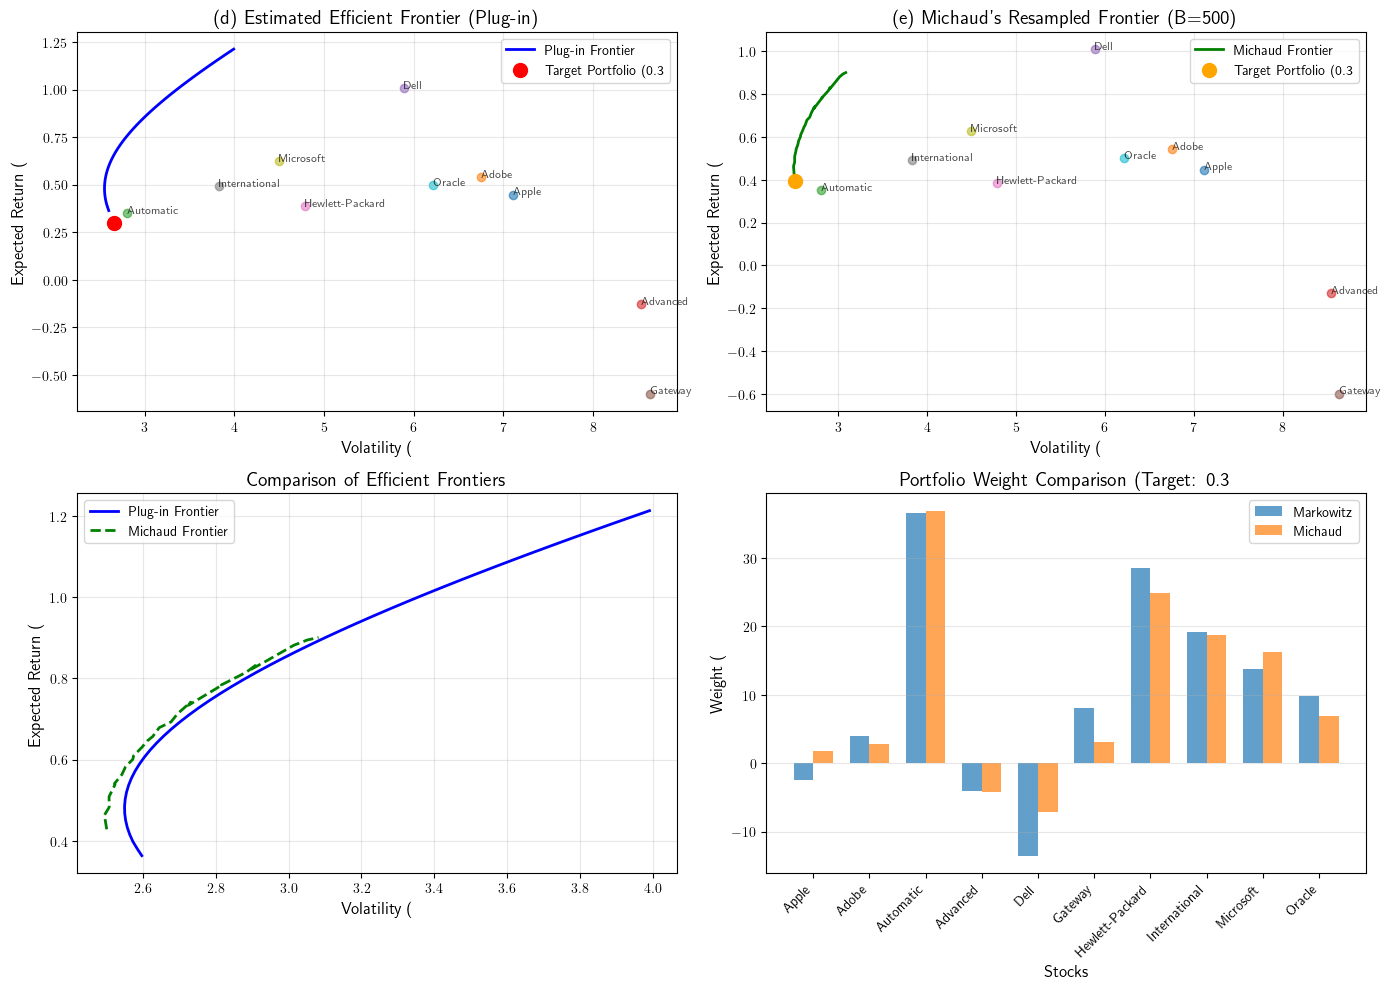


Additional Statistics:
Markowitz Portfolio Sharpe Ratio: 0.1129
Michaud Portfolio Sharpe Ratio: 0.1563
Turnover between portfolios: 13.32%

Standard deviation of bootstrap weights (%):
 1. Apple Computer                          :     6.17%
 2. Adobe Systems                           :     6.51%
 3. Automatic Data Processing               :     9.87%
 4. Advanced Micro Devices                  :     5.99%
 5. Dell                                    :    11.19%
 6. Gateway                                 :     7.03%
 7. Hewlett-Packard Company                 :     6.40%
 8. International Business Machines Corp.   :     6.22%
 9. Microsoft Corp.                         :     6.20%
10. Oracle Corp.                            :     7.28%


In [21]:
# Part (e): Michaud's resampled efficient frontier
def compute_michaud_frontier(returns, B=500, n_points=30):
    """Compute Michaud's resampled efficient frontier"""
    n_assets = returns.shape[1]
    n_obs = returns.shape[0]
    
    # Get range from plug-in frontier
    mu_est = returns.mean().values
    sigma_est = returns.cov().values
    frontier_returns_ref, frontier_volatilities_ref, _ = compute_efficient_frontier(mu_est, sigma_est, n_points)
    
    # Create range of target returns
    mu_min = np.min(frontier_returns_ref)
    mu_max = np.max(frontier_returns_ref)
    mu_targets = np.linspace(mu_min, mu_max, n_points)
    
    michaud_returns = []
    michaud_volatilities = []
    
    for mu_t in mu_targets:
        # Get Michaud's resampled weights for this target return
        w_michaud, _ = michaud_resampled_weights(mu_t, returns, B)
        
        # Compute portfolio statistics using original estimates
        mu_portfolio = w_michaud.T @ mu_est
        vol_portfolio = np.sqrt(w_michaud.T @ sigma_est @ w_michaud)
        
        michaud_returns.append(mu_portfolio)
        michaud_volatilities.append(vol_portfolio)
    
    return np.array(michaud_returns), np.array(michaud_volatilities), mu_targets

# Compute Michaud's frontier
michaud_returns, michaud_volatilities, michaud_targets = compute_michaud_frontier(log_returns, B=500)

# Plotting
plt.figure(figsize=(14, 10))

# Plot (d): Plug-in efficient frontier
plt.subplot(2, 2, 1)
plt.plot(frontier_volatilities * 100, frontier_returns * 100, 'b-', linewidth=2, label='Plug-in Frontier')
plt.scatter(np.sqrt(w_markowitz.T @ sigma_hat @ w_markowitz) * 100, 
            w_markowitz @ emp_means * 100, 
            color='red', s=100, label=f'Target Portfolio (0.3%)', zorder=5)

# Mark individual stocks
for i in range(len(stock_names)):
    vol_i = np.sqrt(sigma_hat[i, i]) * 100
    mu_i = emp_means[i] * 100
    plt.scatter(vol_i, mu_i, alpha=0.6)
    plt.annotate(stock_names[i].split()[0], (vol_i, mu_i), fontsize=8, alpha=0.7)

plt.xlabel('Volatility (%)', fontsize=12)
plt.ylabel('Expected Return (%)', fontsize=12)
plt.title('(d) Estimated Efficient Frontier (Plug-in)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Plot (e): Michaud's resampled efficient frontier
plt.subplot(2, 2, 2)
plt.plot(michaud_volatilities * 100, michaud_returns * 100, 'g-', linewidth=2, label='Michaud Frontier')
plt.scatter(np.sqrt(w_michaud.T @ sigma_hat @ w_michaud) * 100, 
            w_michaud @ emp_means * 100, 
            color='orange', s=100, label=f'Target Portfolio (0.3%)', zorder=5)

# Mark individual stocks
for i in range(len(stock_names)):
    vol_i = np.sqrt(sigma_hat[i, i]) * 100
    mu_i = emp_means[i] * 100
    plt.scatter(vol_i, mu_i, alpha=0.6)
    plt.annotate(stock_names[i].split()[0], (vol_i, mu_i), fontsize=8, alpha=0.7)

plt.xlabel('Volatility (%)', fontsize=12)
plt.ylabel('Expected Return (%)', fontsize=12)
plt.title(f'(e) Michaud\'s Resampled Frontier (B={B})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Plot comparison of both frontiers
plt.subplot(2, 2, 3)
plt.plot(frontier_volatilities * 100, frontier_returns * 100, 'b-', linewidth=2, label='Plug-in Frontier')
plt.plot(michaud_volatilities * 100, michaud_returns * 100, 'g--', linewidth=2, label='Michaud Frontier')
plt.xlabel('Volatility (%)', fontsize=12)
plt.ylabel('Expected Return (%)', fontsize=12)
plt.title('Comparison of Efficient Frontiers', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Plot comparison of portfolio weights
plt.subplot(2, 2, 4)
x = np.arange(len(stock_names))
width = 0.35

# Truncate stock names for display
short_names = [name.split()[0] for name in stock_names]

plt.bar(x - width/2, w_markowitz * 100, width, label='Markowitz', alpha=0.7)
plt.bar(x + width/2, w_michaud * 100, width, label='Michaud', alpha=0.7)

plt.xlabel('Stocks', fontsize=12)
plt.ylabel('Weight (%)', fontsize=12)
plt.title('Portfolio Weight Comparison (Target: 0.3%)', fontsize=14)
plt.xticks(x, short_names, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()

plt.show()

# Additional statistics
print("\n" + "="*80)
print("Additional Statistics:")
print("="*80)

# Compute Sharpe ratios (assuming risk-free rate of 0 for comparison)
rf_rate = 0.0  # Assuming 0% risk-free rate for monthly data
sharpe_markowitz = (w_markowitz @ emp_means - rf_rate) / np.sqrt(w_markowitz.T @ sigma_hat @ w_markowitz)
sharpe_michaud = (w_michaud @ emp_means - rf_rate) / np.sqrt(w_michaud.T @ sigma_hat @ w_michaud)

print(f"Markowitz Portfolio Sharpe Ratio: {sharpe_markowitz:.4f}")
print(f"Michaud Portfolio Sharpe Ratio: {sharpe_michaud:.4f}")

# Compute turnover (difference in weights)
turnover = np.sum(np.abs(w_michaud - w_markowitz)) / 2
print(f"Turnover between portfolios: {turnover*100:.2f}%")

# Bootstrap weight variability
weight_std = np.std(bootstrap_weights, axis=0)
print("\nStandard deviation of bootstrap weights (%):")
for i, (name, std) in enumerate(zip(stock_names, weight_std)):
    print(f"{i+1:2d}. {name:40s}: {std*100:8.2f}%")

# 4.7 

In [22]:
# Data Loading and Processing
def load_and_process_data():
    # Load Market Data (S&P 500 and 3-month T-bill)
    # File has columns: Date, SP500, 3mTCM
    mkt_df = pd.read_csv('m_sp500ret_3mtcm.txt', sep=r'\s+', header=None, skiprows=1)
    mkt_df.columns = ['Date', 'SP500_Ret', '3mTCM']
    mkt_df['Date'] = pd.to_datetime(mkt_df['Date'], format='%b-%y')
    mkt_df.set_index('Date', inplace=True)
    
    # Convert annualized T-bill % to monthly decimal risk-free rate (for convenience we treat it as a simple nominal rate)
    mkt_df['rf'] = (mkt_df['3mTCM'] / 100) / 12

    # Load Stock Data (Log returns)
    # File has columns: Date, AAPL, ADBE, ...
    stk_df = pd.read_csv('m_logret_10stocks.txt', sep=r'\s+')
    stk_df['Date'] = pd.to_datetime(stk_df['Date'])
    stk_df.set_index('Date', inplace=True)
    
    # Convert Log Returns to Simple Returns: R = exp(r) - 1
    stk_simple_ret = np.exp(stk_df) - 1
    
    # Align data (intersection of dates)
    common_dates = mkt_df.index.intersection(stk_simple_ret.index)
    stk_simple_ret = stk_simple_ret.loc[common_dates]
    mkt_df = mkt_df.loc[common_dates]
    
    return stk_simple_ret, mkt_df


a) Using a single-index model (see Exercise 3.3) for the structured covariance matrix $F$, calculate the estimate $\hat{F}$ of $F$ in (4.45).

In [23]:
# Covariance Estimation Methods
def single_index_covariance(stk_returns, mkt_returns):
    """
    Estimates F using Single Index Model: F = beta * beta' * var_m + D
    """
    # X = Market Excess Returns (constant added for intercept)
    X = np.vstack([np.ones(len(mkt_returns)), mkt_returns]).T
    Y = stk_returns.values
    
    # Beta estimation: (X'X)^-1 X'Y
    # Here X has 2 columns (alpha, beta). We want the 2nd coef (beta).
    betas = []
    resid_vars = []
    
    for i in range(Y.shape[1]):
        y_col = Y[:, i]
        coeffs = np.linalg.lstsq(X, y_col, rcond=None)[0]
        beta = coeffs[1]
        
        # Residuals
        y_pred = X @ coeffs
        residuals = y_col - y_pred
        # Residual variance (MLE, divisor T)
        resid_var = np.mean(residuals**2)
        
        betas.append(beta)
        resid_vars.append(resid_var)
        
    betas = np.array(betas).reshape(-1, 1)
    D = np.diag(resid_vars)
    var_m = np.var(mkt_returns, ddof=0) # MLE variance
    
    F_sim = var_m * (betas @ betas.T) + D
    return F_sim

(b)

In [24]:
# Ledoit-Wolf Shrinkage Logic
class LedoitWolfShrinkage:
    def __init__(self, returns):
        """
        returns: DataFrame of asset returns (T x N)
        """
        self.R = returns.values
        self.T, self.N = self.R.shape
        self.means = np.mean(self.R, axis=0)
        
        # Centered returns (y_it)
        self.Y = self.R - self.means
        
        # Sample Covariance Matrix S (using divisor n, consistent with text formulas)
        self.S = (self.Y.T @ self.Y) / self.T
        
        # Pre-compute Pi_hat and Rho_hat components that depend only on Data (S)
        self.pi_hat, self.pi_diag = self._compute_pi_hat()
        self.rho_hat = self._compute_rho_hat()

    def _compute_pi_hat(self):
        # pi_hat_ij = 1/T * sum_t [ (y_it*y_jt - s_ij)^2 ]
        # We can compute this efficiently using numpy broadcasting
        pi_mat = np.zeros((self.N, self.N))
        
        # Loop is clearer for exact implementation of the formula
        for i in range(self.N):
            for j in range(self.N):
                term = (self.Y[:, i] * self.Y[:, j]) - self.S[i, j]
                pi_mat[i, j] = np.mean(term**2) # mean implies 1/T sum
                
        return np.sum(pi_mat), np.diag(pi_mat)

    def _compute_rho_hat(self):
        # 1. Calculate average correlation r_bar
        # r_bar = 2 / (p(p-1)) * sum_{i<j} s_ij / sqrt(s_ii * s_jj)
        correlations = []
        std_devs = np.sqrt(np.diag(self.S))
        
        for i in range(self.N):
            for j in range(i + 1, self.N):
                corr = self.S[i, j] / (std_devs[i] * std_devs[j])
                correlations.append(corr)
        r_bar = np.mean(correlations)
        
        # Calculate Theta terms and Rho
        # rho_hat = sum(pi_ii) + sum_{i} sum_{j!=i} r_bar/2 * (sqrt(s_jj/s_ii)*theta_i,ij + ...)
        
        # Need theta_k_ij. We only need cases where k=i and k=j
        # theta_i,ij = 1/T * sum_t [ (y_it^2 - s_ii)(y_it*y_jt - s_ij) ]
        
        rho_sum_off_diag = 0.0
        
        for i in range(self.N):
            for j in range(self.N):
                if i == j: continue
                
                # Calculate theta_i_ij
                term_i = (self.Y[:, i]**2) - self.S[i, i]
                term_ij = (self.Y[:, i] * self.Y[:, j]) - self.S[i, j]
                theta_i_ij = np.mean(term_i * term_ij)
                
                # Calculate theta_j_ij
                term_j = (self.Y[:, j]**2) - self.S[j, j]
                theta_j_ij = np.mean(term_j * term_ij)
                
                # Term for rho
                sqrt_rat_1 = np.sqrt(self.S[j, j] / self.S[i, i])
                sqrt_rat_2 = np.sqrt(self.S[i, i] / self.S[j, j])
                
                bracket = sqrt_rat_1 * theta_i_ij + sqrt_rat_2 * theta_j_ij
                rho_sum_off_diag += (r_bar / 2.0) * bracket
                
        rho_val = np.sum(self.pi_diag) + rho_sum_off_diag
        return rho_val

    def shrink(self, F_target):
        """
        Calculates shrinkage intensity delta and final matrix using target F.
        """
        # Calculate Gamma Hat
        # gamma = sum_ij (f_ij - s_ij)^2
        gamma_hat = np.sum((F_target - self.S)**2)
        
        # Calculate Delta
        # kappa = (pi - rho) / gamma
        kappa = (self.pi_hat - self.rho_hat) / gamma_hat
        
        # delta = max(0, min(1, kappa/T))
        delta = max(0, min(1, kappa / self.T))
        
        # Final Estimator
        Sigma_hat = delta * F_target + (1 - delta) * self.S
        
        return Sigma_hat, delta

(c) Perform PCA on the ten stocks. Using the first two principal components as factors in a two-factor model for $F$ (see Section 3.4.3), estimate $F$

In [25]:
def pca_covariance(stk_returns, n_components=2):
    """
    Estimates F using PCA Factor Model (k=2).
    Standardize -> PCA -> Reconstruct Covariance
    """
    # Correlation matrix
    corr_mat = stk_returns.corr()
    std_devs = stk_returns.std(ddof=0) # MLE std for consistency
    
    # PCA on Correlation
    pca = PCA(n_components=n_components)
    pca.fit(corr_mat)
    
    # Get loadings (L) = eigenvectors * sqrt(eigenvalues)
    # In sklearn: components_ are eigenvectors * sqrt(evals)
    # explained_variance_ are eigenvalues.
    L = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    # Reconstruct Correlation: R_hat = L * L.T + Psi
    # Psi is diagonal of (Real Corr - L*L.T)
    R_common = L @ L.T
    R_resid = np.diag(np.diag(corr_mat - R_common))
    R_hat = R_common + R_resid
    
    # Convert back to Covariance: Sigma_hat = D * R_hat * D
    D_std = np.diag(std_devs)
    F_pca = D_std @ R_hat @ D_std
    
    return F_pca

(d) Using the estimated $\hat{F}$ in (c) as the shrinkage target in (4.45), compute the new value of $\hat{\delta}$ and the new shrinkage estimate (4.45) of $\Sigma$. Plot the corresponding estimated efficient frontier and compare it with that in (b).

In [26]:
# Efficient Frontier Plotting
def calculate_frontier(mu, Sigma, num_points=100):
    """
    Calculates (std, ret) points for efficient frontier (with short selling).
    """
    ones = np.ones(len(mu))
    Sigma_inv = np.linalg.inv(Sigma)
    
    A = ones.T @ Sigma_inv @ ones
    B = ones.T @ Sigma_inv @ mu
    C = mu.T @ Sigma_inv @ mu
    delta = A*C - B**2
    
    # Range of returns
    mu_min = np.min(mu)
    mu_max = np.max(mu)
    target_mus = np.linspace(mu_min * 0.9, mu_max * 1.2, num_points)
    
    target_vars = (A * target_mus**2 - 2*B * target_mus + C) / delta
    target_stds = np.sqrt(target_vars)
    
    return target_stds, target_mus

## 4.7 Results (main execution)

Part (a): F_SIM computed.
Part (b): Optimal Shrinkage Intensity (SIM): 0.328881
Part (c): F_PCA computed.
Part (d): Optimal Shrinkage Intensity (PCA): 0.074511


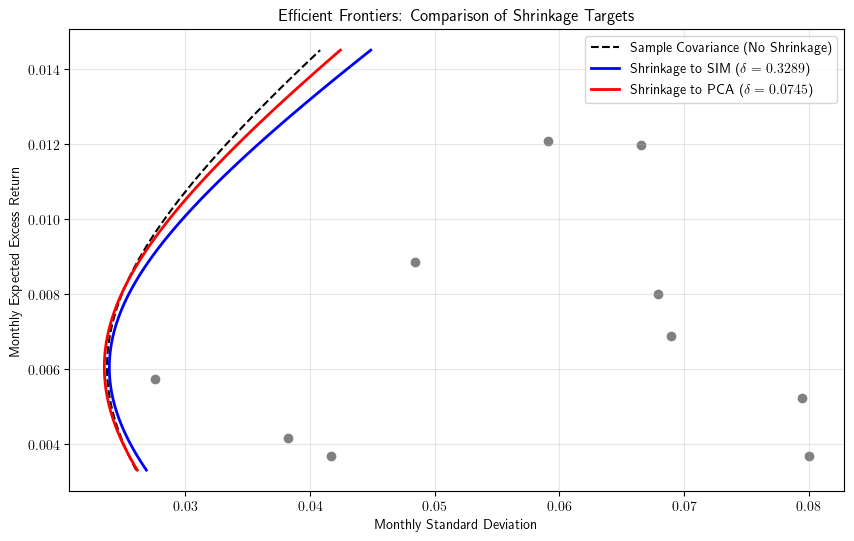

In [27]:
# Main Execution

# Load Data
stk_ret, mkt_df = load_and_process_data()

# Excess Returns
stk_excess = stk_ret.sub(mkt_df['rf'], axis=0)
mkt_excess = mkt_df['SP500_Ret'] - mkt_df['rf']

# Part (a): Single Index Model F
F_sim = single_index_covariance(stk_excess, mkt_excess)
print("Part (a): F_SIM computed.")

# Part (b): Shrinkage with F_SIM 
lw = LedoitWolfShrinkage(stk_excess)
Sigma_sim, delta_sim = lw.shrink(F_sim)

print(f"Part (b): Optimal Shrinkage Intensity (SIM): {delta_sim:.6f}")

# Part (c): PCA Factor Model F
# Using raw stock returns for correlation structure (standard practice) or excess?
# Covariance of excess returns is same as covariance of raw returns (rf is constant per month)
F_pca = pca_covariance(stk_excess, n_components=2)
print("Part (c): F_PCA computed.")

# Part (d): Shrinkage with F_PCA
Sigma_pca, delta_pca = lw.shrink(F_pca)
print(f"Part (d): Optimal Shrinkage Intensity (PCA): {delta_pca:.6f}")

# Plotting 
mu = stk_excess.mean().values

std_sim, mu_sim = calculate_frontier(mu, Sigma_sim)
std_pca, mu_pca = calculate_frontier(mu, Sigma_pca)
std_sample, mu_sample = calculate_frontier(mu, lw.S) # For reference

plt.figure(figsize=(10, 6))
plt.plot(std_sample, mu_sample, 'k--', label='Sample Covariance (No Shrinkage)')
plt.plot(std_sim, mu_sim, 'b-', linewidth=2, label=rf'Shrinkage to SIM ($\delta={delta_sim:.4f}$)')
plt.plot(std_pca, mu_pca, 'r-', linewidth=2, label=rf'Shrinkage to PCA ($\delta={delta_pca:.4f}$)')

# Plot individual assets
stk_stds = np.sqrt(np.diag(lw.S))
plt.scatter(stk_stds, mu, c='gray', marker='o')

plt.title('Efficient Frontiers: Comparison of Shrinkage Targets')
plt.xlabel('Monthly Standard Deviation')
plt.ylabel('Monthly Expected Excess Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()